<a href="https://colab.research.google.com/github/cosmicurvy/amazon-reviews-nlp/blob/main/notebooks/DistilBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip uninstall -y transformers
!pip install transformers==4.48.0 tf-keras

In [3]:
# importing the required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import tensorflow as tf
import transformers
from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification
from tf_keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

# to ingore warnings
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("/content/drive/MyDrive/Sentiment-Classification/amazon_reviews.csv")
df.sample(5)

,title,text,rating
45271,"Great sound, small and easy to travel with","My 22 year old son, who is a professional musi...",4
43473,Good strap for bass guitar.,Very happy with this strap. Was concerned abou...,5
37695,Five Stars,Very nice effect.,5
18214,Really useful item. Well designed and arrived ...,Really useful item. Well designed and arrived ...,5
19898,very good,Like,4


In [5]:
df.shape

(50000, 3)

In [6]:
print(df.isnull().sum())
df.dropna(inplace=True)
print("\n")
print(df.shape)

title     6
text      5
rating    0
dtype: int64


(49989, 3)


- The objective is to build a binary classifier. Since reviews with a rating of 3 often express mixed sentiment, it is preferable to remove them.

In [7]:
df = df[df['rating' ] != 3]

- The function below labels reviews with ratings of 1 and 2 as 0 (negative), and reviews with ratings of 4 and 5 as 1 (positive).

In [8]:
# function to get the sentiment for each review
def get_sentiment(rate):
  if rate in [1, 2]:
    return 0
  else:
    return 1
df['sentiment'] = df['rating'].apply(get_sentiment)

In [9]:
df.sample(5)

,title,text,rating,sentiment
1569,Loved it,Gifted to my husband he loved it ! The sound i...,5,1
48190,Works great on my Jazzmaster,Works great on my Jazzmaster. Good clean signa...,5,1
12619,Fantastic craftsmanship.,Absolutely beautiful mat. A very classy looki...,5,1
19702,Nice product. Great Seller!,I love how small this is. It fits at the botto...,5,1
7667,Where's the beef?,"These are good speakers for the price, althoug...",4,1


In [10]:
df.sentiment.value_counts()

,count
sentiment,
1,39684
0,6874


- Tha dataset is highly imbalanced.

In [11]:
# spliting the training and test sets
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['sentiment'], test_size=0.2, random_state=35)

## Model Training

- DistilBERT is a compressed version of BERT that distils BERT's knowledge into a smaller model with fewer parameters, lower memory usage and significantly faster inference.

- In this project, the DistilBERT tokenizer is used to prepare the text and the DistilBERT model is used for sentiment classification.

In [12]:
model_name = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = TFDistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_projector.bias', 'vocab_transform.weight', 'vocab_layer_norm.weight', 'vocab_layer_norm.bias', 'vocab_transform.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

In [13]:
MAX_LEN = 128
BATCH_SIZE = 32
EPOCHS = 3

In [14]:
# tokenizing and encoding the training and test sets
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LEN,
    return_tensors='tf'
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LEN,
    return_tensors='tf'
)

In [15]:
print(train_encodings['input_ids'][0])

tf.Tensor(
[ 101 2204 2614  102    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0], shape=(128,), dtype=int32)


In [16]:
print(train_encodings['attention_mask'][0])

tf.Tensor(
[1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0], shape=(128,), dtype=int32)


- `attention_mask` ignores padding values.

In [17]:
len(X_train.tolist())

37246

In [18]:
len(y_train.tolist())

37246

- Tokenizer outputs and labels are converted into a tensorflow dataset for model input.

In [19]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        {
            'input_ids' : train_encodings['input_ids'],
            'attention_mask' : train_encodings['attention_mask']
        },
        y_train
    )

)


test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        {
            'input_ids' : test_encodings['input_ids'],
            'attention_mask' : test_encodings['attention_mask']
        },
        y_test
    )

)

- `shuffle` adds randomness to the training data.

- `drop_remainder=True` ensures that each batch contains 32 samples by dropping leftover data at end of the epoch that does not fit into a full fatch.

In [20]:
train_dataset = (train_dataset.shuffle(1000).batch(BATCH_SIZE, drop_remainder=True))

In [21]:
# optimizer
optimizer = Adam(learning_rate=5e-5)
# loss
loss = SparseCategoricalCrossentropy(from_logits=True)

In [22]:
model.compile(optimizer=optimizer,
              loss = loss,
              metrics= 'accuracy')

model.summary()

Model: "tf_distil_bert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 distilbert (TFDistilBertMa  multiple                  66362880  
 inLayer)                                                        
                                                                 
 pre_classifier (Dense)      multiple                  590592    
                                                                 
 classifier (Dense)          multiple                  1538      
                                                                 
 dropout_19 (Dropout)        multiple                  0 (unused)
                                                                 
Total params: 66955010 (255.41 MB)
Trainable params: 66955010 (255.41 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [23]:
# training the model for three epochs
history = model.fit(train_dataset, epochs = EPOCHS)

Epoch 1/3
1163/1163 [==============================] - 510s 413ms/step - loss: 0.1480 - accuracy: 0.9433
Epoch 2/3
1163/1163 [==============================] - 481s 413ms/step - loss: 0.0790 - accuracy: 0.9722
Epoch 3/3
1163/1163 [==============================] - 480s 413ms/step - loss: 0.0481 - accuracy: 0.9844


In [24]:
history.history

{'loss': [0.14803040027618408, 0.07895463705062866, 0.04805820435285568],
 'accuracy': [0.9432770609855652, 0.9721893668174744, 0.9843884110450745]}

In [25]:
test_dataset = test_dataset.batch(BATCH_SIZE)

In [26]:
loss, acc = model.evaluate(test_dataset)
print("Loss on test data: ", loss)
print("Accuracy on test data: ", acc)

291/291 [==============================] - 52s 169ms/step - loss: 0.1374 - accuracy: 0.9520
Loss on test data:  0.137422576546669
Accuracy on test data:  0.9519973993301392


- After training for three epochs, the DistilBERT Model achieved 95% accuracy on the test data.

291/291 [==============================] - 45s 149ms/step


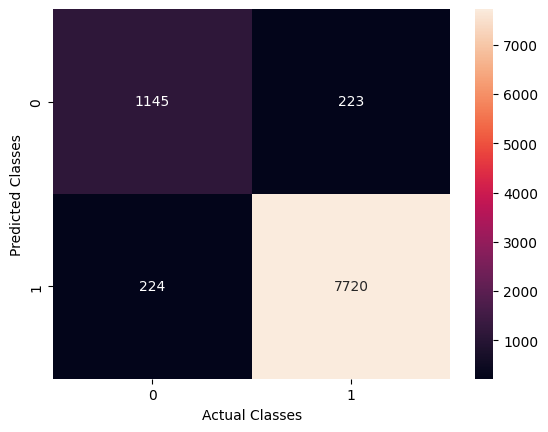

In [27]:
# confusion matrix
predictions = model.predict(test_dataset)
logits = predictions.logits
predicted_labels = np.argmax(logits, axis=1)

sns.heatmap(confusion_matrix(y_test, predicted_labels), annot=True, fmt='.0f')
plt.xlabel("Actual Classes")
plt.ylabel("Predicted Classes")
plt.show()

In [28]:
# function to predict the sentiment of unseen reviews
def make_prediction(text):
  input = tokenizer(text,
                     truncation=True,
                     padding=True,
                     return_tensors="tf"
                     )
  pred = model.predict(input)
  logits = pred['logits']

  probs = tf.nn.softmax(logits)

  predicted_cls = np.argmax(probs, axis=1)[0]

  if predicted_cls == 0:
    return "Negative"
  else:
    return "Positive"

In [30]:
# reviews for testing
text1 = "Well made, good fit & finish, does the job!  If you don't want to spend the money for an enclosed rack case, this is a good alternative."
text2 = "Lost its tuning every single day . Had to return it."

In [31]:
make_prediction(text1)

1/1 [==============================] - 3s 3s/step


'Positive'

In [32]:
make_prediction(text2)

1/1 [==============================] - 1s 1s/step


'Negative'

In [33]:
# saving the tokenizer and model
tokenizer.save_pretrained('/content/drive/MyDrive/Sentiment-Classification/distilbert_tokenizer.zip')
model.save_pretrained('/content/drive/MyDrive/Sentiment-Classification/distilbert_model.zip')